IHK

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Merged_IHK_Februari.csv')

# Melihat 5 data awal
print(df.head())

       Daerah    2015    2016    2017    2018    2019    2020    2021    2022  \
0  BANYUWANGI  116.57  121.15  123.74  127.47  129.36  102.88  104.32  105.95   
1   BULUKUMBA  124.24  127.58  132.55  138.73  142.53  105.18  107.05  109.29   
2       BUNGO  116.86  121.76  125.34  129.79  132.94  104.68  105.98  108.77   
3     CILACAP  120.73  125.18  130.74  135.73  137.83  102.97  104.66  106.99   
4        DILI       -       -       -       -       -     NaN     NaN     NaN   

     2023  2024  2025  2026  
0  112.72   NaN   NaN   NaN  
1  114.24   NaN   NaN   NaN  
2  115.25   NaN   NaN   NaN  
3  114.26   NaN   NaN   NaN  
4     NaN   NaN   NaN   NaN  


In [3]:
print(df.columns)

Index(['Daerah', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       '2022', '2023', '2024', '2025', '2026'],
      dtype='object')


In [11]:
long_df = df.melt(
    id_vars='Daerah',
    var_name='Tahun',
    value_name='IHK'
)

long_df['IHK'] = pd.to_numeric(
    long_df['IHK'],
    errors='coerce'
)

In [12]:
long_df['Tahun'] = long_df['Tahun'].astype(int)

In [13]:
long_df = long_df.sort_values(
    ['Daerah', 'Tahun']
)

In [14]:
print(long_df.isnull().sum())

Daerah       0
Tahun        0
IHK       1408
dtype: int64


In [15]:
long_df['IHK'] = long_df['IHK'].fillna(
    long_df['IHK'].median()
)

In [16]:
print(long_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2304 entries, 0 to 2303
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Daerah  2304 non-null   object 
 1   Tahun   2304 non-null   int64  
 2   IHK     2304 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 72.0+ KB
None


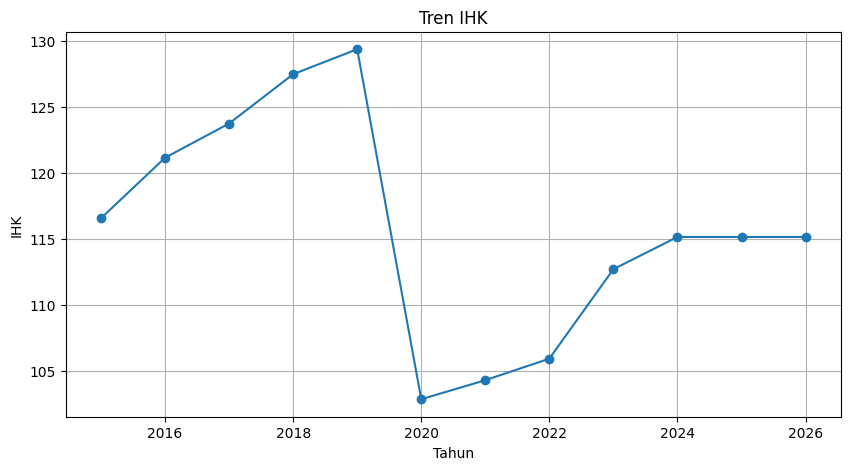

In [17]:
sample = long_df[
    long_df['Daerah'] == long_df['Daerah'].iloc[0]
]

plt.figure(figsize=(10,5))

plt.plot(
    sample['Tahun'],
    sample['IHK'],
    marker='o'
)

plt.title("Tren IHK")

plt.xlabel("Tahun")
plt.ylabel("IHK")

plt.grid(True)

plt.show()

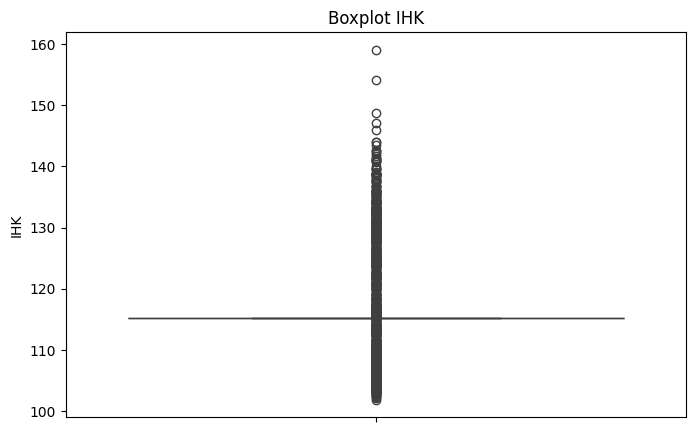

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(data=long_df['IHK'])

plt.title("Boxplot IHK")

plt.show()

In [19]:
clean_df = long_df.copy()

lower = clean_df['IHK'].quantile(0.10)
upper = clean_df['IHK'].quantile(0.90)

clean_df['IHK'] = np.clip(
    clean_df['IHK'],
    lower,
    upper
)

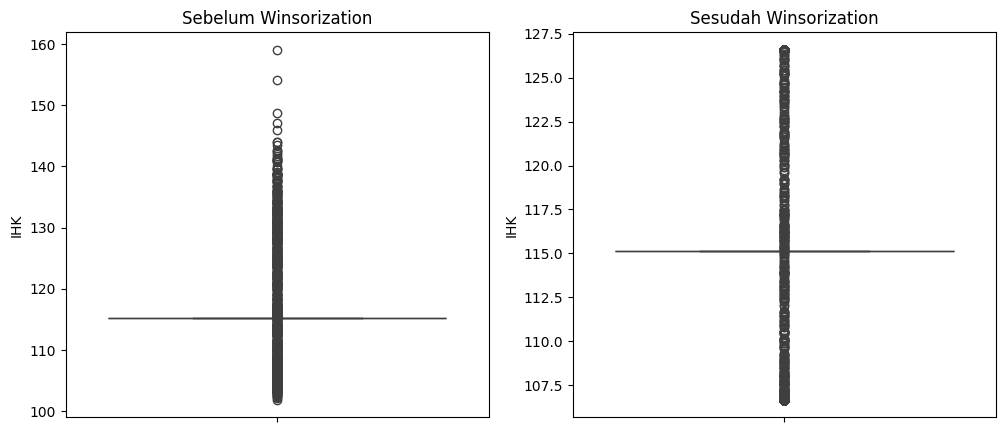

In [20]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(
    data=long_df['IHK'],
    ax=axes[0]
)

axes[0].set_title("Sebelum Winsorization")

sns.boxplot(
    data=clean_df['IHK'],
    ax=axes[1]
)

axes[1].set_title("Sesudah Winsorization")

plt.show()

In [21]:
clean_df['Trend'] = (
    clean_df['Tahun']
    - clean_df['Tahun'].min()
)

In [22]:
clean_df['Lag1'] = (
    clean_df.groupby('Daerah')['IHK']
    .shift(1)
)

In [23]:
clean_df['Lag2'] = (
    clean_df.groupby('Daerah')['IHK']
    .shift(2)
)

In [24]:
clean_df['Lag3'] = (
    clean_df.groupby('Daerah')['IHK']
    .shift(3)
)

In [25]:
clean_df['Diff1'] = (
    clean_df.groupby('Daerah')['IHK']
    .diff(1)
)

In [26]:
clean_df['Growth_%'] = (
    clean_df.groupby('Daerah')['IHK']
    .pct_change()
) * 100

In [27]:
clean_df['RollingMean3'] = (

    clean_df.groupby('Daerah')['IHK']

    .rolling(3)

    .mean()

    .reset_index(0, drop=True)
)

In [28]:
clean_df['RollingSTD3'] = (

    clean_df.groupby('Daerah')['IHK']

    .rolling(3)

    .std()

    .reset_index(0, drop=True)
)

In [29]:
clean_df['ExpandingMean'] = (

    clean_df.groupby('Daerah')['IHK']

    .expanding()

    .mean()

    .reset_index(level=0, drop=True)
)

In [30]:
clean_df.isnull().sum()

,0
Daerah,0
Tahun,0
IHK,0
Trend,0
Lag1,192
Lag2,384
Lag3,576
Diff1,192
Growth_%,192
RollingMean3,384


In [31]:
model_df = clean_df.dropna()

In [32]:
model_df.head()

,Daerah,Tahun,IHK,Trend,Lag1,Lag2,Lag3,Diff1,Growth_%,RollingMean3,RollingSTD3,ExpandingMean
576,BANYUWANGI,2018,126.594,3,123.740,121.150,116.570,2.854,2.306449,123.828000,2.723067,122.013500
768,BANYUWANGI,2019,126.594,4,126.594,123.740,121.150,0.000,0.000000,125.642667,1.647758,122.929600
960,BANYUWANGI,2020,106.679,5,126.594,126.594,123.740,-19.915,-15.731393,119.955667,11.497931,120.221167
1152,BANYUWANGI,2021,106.679,6,106.679,126.594,126.594,0.000,0.000000,113.317333,11.497931,118.286571
1344,BANYUWANGI,2022,106.679,7,106.679,106.679,126.594,0.000,0.000000,106.679000,0.000000,116.835625


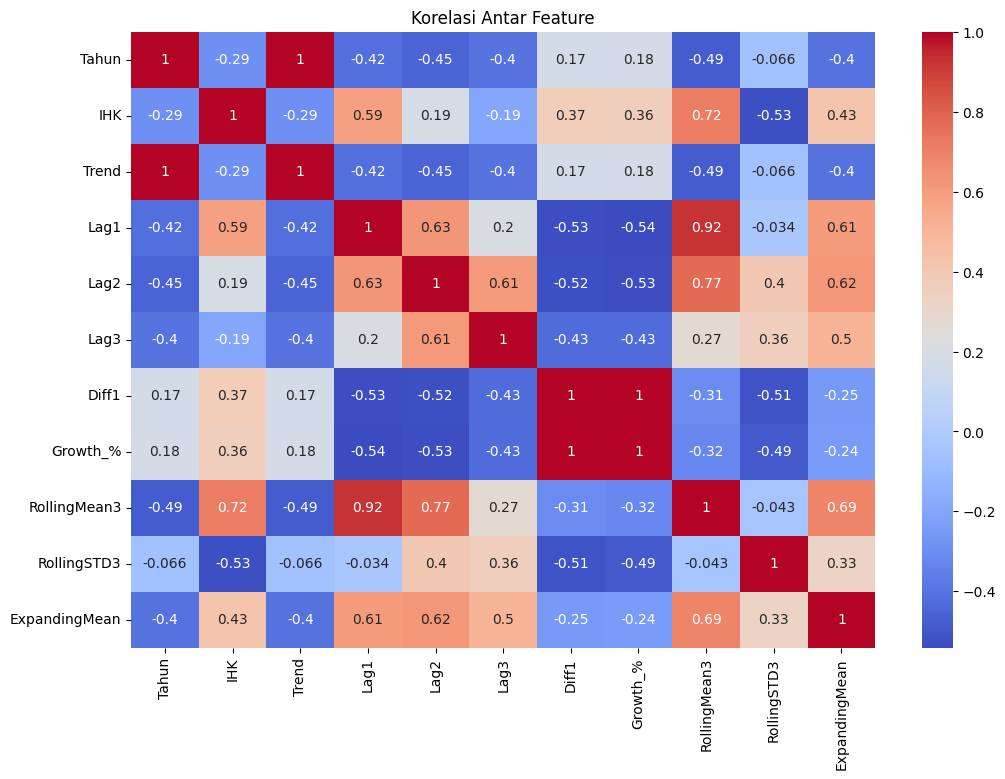

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    model_df.drop(columns=['Daerah']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Korelasi Antar Feature")

plt.show()

In [34]:
train_df = model_df[
    model_df['Tahun'] < 2025
]

test_df = model_df[
    model_df['Tahun'] >= 2025
]

In [35]:
X_train = train_df.drop(
    columns=['Daerah', 'IHK']
)

y_train = train_df['IHK']

X_test = test_df.drop(
    columns=['Daerah', 'IHK']
)

y_test = test_df['IHK']

In [36]:
model_df.to_csv(
    "dataset_forecasting_final.csv",
    index=False
)